                      Week 7 – Feedforward Neural Networks
                            Student ID: 259050589

This notebook implements and analyses feedforward neural networks using the Heart Failure Clinical Records dataset.

The objectives are:

Compare logistic regression with a neural network
Study the role of nonlinear activation functions
Analyse model capacity and overfitting
Perform responsible model evaluation using train/validation/test splits

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score

import torch
import torch.nn as nn
import torch.optim as optim

## Load the Dataset

The Heart Failure Clinical Records dataset contains 299 patient records with
clinical measurements used to predict survival outcomes.

In [3]:
data = pd.read_csv("heart_failure_clinical_records_dataset.csv")

data.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## Data Preparation

The target variable is DEATH_EVENT, meaning the patient died during the follow-up period. Features are standardised before training neural networks.

In [13]:
print(data.shape)

data.info()

data.describe()

(299, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


## Feature and Target Separation

The target variable is **DEATH_EVENT**, which indicates whether the patient
died during the follow-up period.

In [14]:
X = data.drop("DEATH_EVENT", axis=1).values
y = data["DEATH_EVENT"].values

## Train, Validation and Test Split

The dataset is split into:

- Training set
- Validation set
- Test set

Stratification is used to maintain class balance.

In [15]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

## Feature Standardisation

Neural networks train more effectively when features are standardised.

In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## Convert Data to PyTorch Tensors

In [17]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
y_val = torch.tensor(y_val, dtype=torch.float32).view(-1,1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)

## Logistic Regression Model

Logistic regression is a linear model defined as:

p(y=1|x) = σ(wᵀx + b)

This model does not contain hidden layers and therefore produces a linear decision boundary.

In [18]:
class LogisticRegressionModel(nn.Module):

    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim,1)

    def forward(self,x):
        return torch.sigmoid(self.linear(x))

## Model Training Function

In [20]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=100):

    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):

        model.train()

        optimizer.zero_grad()

        pred = model(X_train)

        loss = criterion(pred, y_train)

        loss.backward()

        optimizer.step()

        model.eval()

        with torch.no_grad():

            val_pred = model(X_val)

            val_loss = criterion(val_pred, y_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

    return train_losses, val_losses

## Train Logistic Regression

In [21]:
input_dim = X_train.shape[1]

log_model = LogisticRegressionModel(input_dim)

train_losses_lr, val_losses_lr = train_model(
    log_model,
    X_train,
    y_train,
    X_val,
    y_val
)

## Multi-Layer Perceptron (MLP)

A neural network with one hidden layer and nonlinear activation
increases the representational capacity of the model.

In [22]:
class MLP(nn.Module):

    def __init__(self, input_dim, hidden_units, activation="relu"):

        super().__init__()

        if activation == "relu":
            act = nn.ReLU()
        else:
            act = nn.Tanh()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_units),
            act,
            nn.Linear(hidden_units,1),
            nn.Sigmoid()
        )

    def forward(self,x):
        return self.network(x)

## Train Neural Network with ReLU Activation

In [24]:
mlp_relu = MLP(input_dim, 32, "relu")

train_losses_relu, val_losses_relu = train_model(
    mlp_relu,
    X_train,
    y_train,
    X_val,
    y_val
)

## Training and Validation Curves

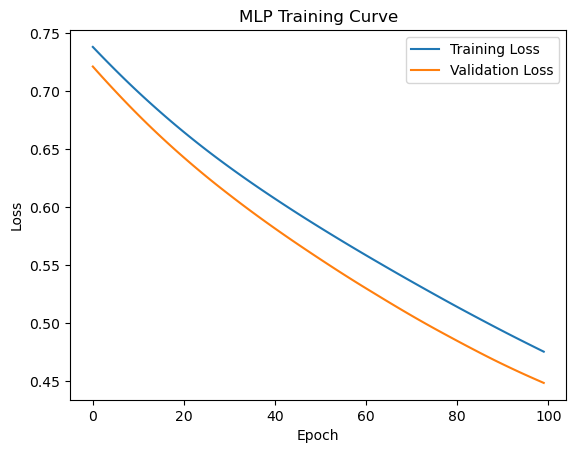

In [25]:
plt.plot(train_losses_relu, label="Training Loss")
plt.plot(val_losses_relu, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.title("MLP Training Curve")

plt.show()

## Activation Function Comparison

Two identical networks are trained using:

- ReLU
- tanh

In [26]:
mlp_tanh = MLP(input_dim, 32, "tanh")

train_losses_tanh, val_losses_tanh = train_model(
    mlp_tanh,
    X_train,
    y_train,
    X_val,
    y_val
)

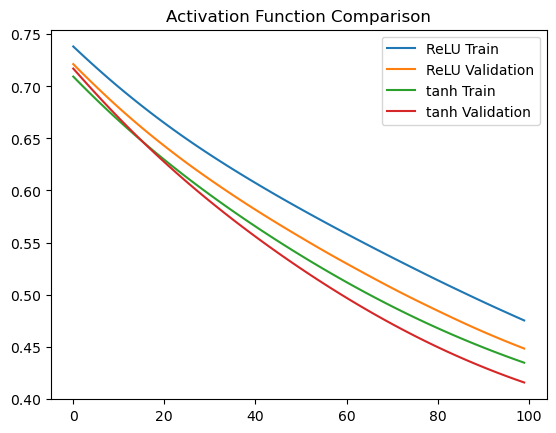

In [27]:
plt.plot(train_losses_relu, label="ReLU Train")
plt.plot(val_losses_relu, label="ReLU Validation")

plt.plot(train_losses_tanh, label="tanh Train")
plt.plot(val_losses_tanh, label="tanh Validation")

plt.legend()

plt.title("Activation Function Comparison")

plt.show()

## Network Capacity Comparison

Two networks are compared:

Small network: 8 hidden units  
Large network: 128 hidden units

In [28]:
small_net = MLP(input_dim, 8, "relu")
large_net = MLP(input_dim, 128, "relu")

train_small, val_small = train_model(
    small_net,
    X_train,
    y_train,
    X_val,
    y_val
)

train_large, val_large = train_model(
    large_net,
    X_train,
    y_train,
    X_val,
    y_val
)

## Final Test Evaluation

The test set is used only once after model design decisions
have been finalised.

In [29]:
def evaluate(model, X, y):

    model.eval()

    with torch.no_grad():

        pred = model(X)

    pred_class = (pred > 0.5).float()

    acc = accuracy_score(y, pred_class)

    auc = roc_auc_score(y, pred)

    return acc, auc

In [30]:
acc, auc = evaluate(mlp_relu, X_test, y_test)

print("Test Accuracy:", acc)

print("Test ROC AUC:", auc)

Test Accuracy: 0.8
Test ROC AUC: 0.8087557603686636


## Analysis

### Logistic Regression

Logistic Regression is a linear model, as predictions depend on a linear combination of the input features.

## Neural Network
    
Nonlinear activation functions introduced in the MLP allow the model to express more complex interactions between variables.

## Activation Functions

ReLU usually converges more quickly since it has no gradient saturation. The tanh activation function may experience vanishing gradients.

## Model Capacity
    
As the hidden quantity increases, the model capacity will also increase with it, but too many hidden units raise the risk of overfitting when training data is limited.

## Responsible Evaluation
    
To guide architectural decisions, the validation set is utilised first. The final evaluation only needs to be performed using the test set to gain an unbiased performance estimate.